Các bước thực hiện trong colab này:
+ Đọc dữ liệu
+ Clean data
+ Xử lý outlier bằng Zscore
+ Cho vào SMOTE
+ MFCM
+ Chia dữ liệu train, test
+ Scale tập train, test
+ Cho vào mô hình
- tỉ lệ trên tập test cân bằng là

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/DATN/fetal_health.csv'
data = pd.read_csv(file_path)
display(data.head())

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [4]:
negative_values_found = False
for column in data.select_dtypes(include=['number']).columns:
    negative_count = (data[column] < 0).sum()
    if negative_count > 0:
        print(f"Cột '{column}' có {negative_count} giá trị nhỏ hơn 0.")
        negative_values_found = True

if not negative_values_found:
    print("Không tìm thấy giá trị nào nhỏ hơn 0 trong các cột số.")

Cột 'histogram_tendency' có 165 giá trị nhỏ hơn 0.


In [5]:
data["histogram_tendency"].value_counts()

,count
histogram_tendency,
0.0,1115
1.0,846
-1.0,165


In [6]:
data["fetal_health"].value_counts()

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


Clean data

In [7]:
data.duplicated().sum()

np.int64(13)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
# =============================
# Xử lý giá trị thiếu sau khi xoá duplicate
# =============================

print("Kích thước dữ liệu sau khi xoá duplicate:", data.shape)

# Kiểm tra số lượng giá trị thiếu trên từng cột
missing_values = data.isna().sum()
missing_percent = (data.isna().sum() / len(data)) * 100

missing_table = pd.DataFrame({
    "Số lượng giá trị thiếu": missing_values,
    "Tỷ lệ thiếu (%)": missing_percent
})

print("Bảng kiểm tra giá trị thiếu:")
display(missing_table)

# Tổng số giá trị thiếu trong toàn bộ dữ liệu
total_missing = data.isna().sum().sum()
print("Tổng số giá trị thiếu trong dữ liệu:", total_missing)

# =============================
# Xử lý nếu có giá trị thiếu
# =============================

if total_missing > 0:
    target_col = "fetal_health"

    # Nếu cột đầu ra bị thiếu thì xoá dòng đó
    if data[target_col].isna().sum() > 0:
        print(f"Số giá trị thiếu ở biến mục tiêu {target_col}: {data[target_col].isna().sum()}")
        data = data.dropna(subset=[target_col])
        print("Đã xoá các dòng bị thiếu ở biến mục tiêu.")

    # Lấy các cột số, ngoại trừ biến mục tiêu
    num_cols = data.select_dtypes(include=["int64", "float64"]).columns
    num_cols = [col for col in num_cols if col != target_col]

    # Thay giá trị thiếu của các cột số bằng median
    for col in num_cols:
        if data[col].isna().sum() > 0:
            median_value = data[col].median()
            data[col] = data[col].fillna(median_value)
            print(f"Đã thay giá trị thiếu ở cột {col} bằng median = {median_value}")

else:
    print("Dữ liệu không có giá trị thiếu, không cần xử lý.")

# Reset index sau khi xử lý
data = data.reset_index(drop=True)

# Kiểm tra lại sau xử lý
print("\nTổng số giá trị thiếu sau xử lý:", data.isna().sum().sum())
print("Kích thước dữ liệu sau xử lý giá trị thiếu:", data.shape)

display(data.head())

Kích thước dữ liệu sau khi xoá duplicate: (2113, 22)
Bảng kiểm tra giá trị thiếu:


,Số lượng giá trị thiếu,Tỷ lệ thiếu (%)
baseline value,0,0.0
accelerations,0,0.0
fetal_movement,0,0.0
uterine_contractions,0,0.0
light_decelerations,0,0.0
severe_decelerations,0,0.0
prolongued_decelerations,0,0.0
abnormal_short_term_variability,0,0.0
mean_value_of_short_term_variability,0,0.0
percentage_of_time_with_abnormal_long_term_variability,0,0.0


Tổng số giá trị thiếu trong dữ liệu: 0
Dữ liệu không có giá trị thiếu, không cần xử lý.

Tổng số giá trị thiếu sau xử lý: 0
Kích thước dữ liệu sau xử lý giá trị thiếu: (2113, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2113.0,133.304780,9.837451,106.0,126.000,133.000,140.000,160.000
accelerations,2113.0,0.003188,0.003871,0.0,0.000,0.002,0.006,0.019
fetal_movement,2113.0,0.009517,0.046804,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2113.0,0.004387,0.002941,0.0,0.002,0.005,0.007,0.015
light_decelerations,2113.0,0.001901,0.002966,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2113.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2113.0,0.000159,0.000592,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2113.0,46.993848,17.177782,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2113.0,1.335021,0.884368,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2113.0,9.795078,18.337073,0.0,0.000,0.000,11.000,91.000


Outlier Zscore

In [12]:
from scipy.stats import zscore
import numpy as np
import pandas as pd

# Tách cột đầu vào và cột đầu ra
X = data.drop(columns=['fetal_health'])
y = data['fetal_health']

# Chỉ lấy các cột số trong X
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Tính Z-score cho các cột số
z_scores = np.abs(zscore(X[num_cols], nan_policy='omit'))

# Nếu chỉ có 1 cột số thì đưa về DataFrame cho đồng nhất
if len(num_cols) == 1:
    z_scores = pd.DataFrame(z_scores, columns=num_cols, index=X.index)
else:
    z_scores = pd.DataFrame(z_scores, columns=num_cols, index=X.index)

# Đặt ngưỡng Z-score
threshold = 3.5

# Giữ lại các dòng không có outlier
mask = (z_scores < threshold).all(axis=1)

X_clean = X[mask]
y_clean = y[mask]

# Ghép lại thành dataframe mới nếu cần
data_clean = pd.concat([X_clean, y_clean], axis=1)

print("Kích thước trước khi xử lý:", data.shape)
print("Kích thước sau khi xử lý:", data_clean.shape)

Kích thước trước khi xử lý: (2113, 22)
Kích thước sau khi xử lý: (1920, 22)


In [13]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 34.8 MB/s eta 0:00:00


Thực thi

In [14]:
# Nếu chưa cài thư viện thì chạy dòng này trước
# !pip install scikit-fuzzy

import pandas as pd
import numpy as np
import skfuzzy as fuzz

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score
)

target_col = 'fetal_health'

print("Kích thước data gốc:", data_clean.shape)
display(data_clean.head())

# =============================
# 1. Tách X, y từ toàn bộ data
# =============================
X = data_clean.drop(columns=[target_col]).copy()
y = data_clean[target_col].copy().astype(int)

print("\nPhân bố lớp ban đầu:")
print(y.value_counts().sort_index())

# =============================
# 2. SMOTE trên toàn bộ data
# =============================
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

X_smote, y_smote = smote.fit_resample(X, y)

X_smote = pd.DataFrame(X_smote, columns=X.columns)
y_smote = pd.Series(y_smote, name=target_col)

print("\nPhân bố lớp sau SMOTE toàn bộ data:")
print(y_smote.value_counts().sort_index())

print("\nKích thước sau SMOTE:")
print("X_smote:", X_smote.shape)
print("y_smote:", y_smote.shape)

# =============================
# 3. Chia train/test sau khi SMOTE
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X_smote,
    y_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_smote
)

print("\nPhân bố y_train:")
print(y_train.value_counts().sort_index())

print("\nPhân bố y_test:")
print(y_test.value_counts().sort_index())

# =============================
# 4. Scale sau khi chia
# =============================
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("\nĐã scale xong dữ liệu")

# =========================================================
# 5. FCM: train trên train set và lấy membership làm feature
# =========================================================

# Chuyển sang numpy
DataCV_train = X_train_scaled.values
DataCV_test = X_test_scaled.values

# Số cụm
c = 2
m = 2

# Tham số hội tụ
error = 0.005
maxiter = 1000

# =============================
# Train FCM trên tập train
# =============================
# Lưu ý:
# skfuzzy yêu cầu dữ liệu đầu vào có dạng:
# số_feature x số_mẫu
# nên cần truyền DataCV_train.T

cntr, U_train_fcm, U0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data=DataCV_train.T,
    c=c,
    m=m,
    error=error,
    maxiter=maxiter,
    init=None,
    seed=42
)

print("\nĐã train FCM xong")
print("Tâm cụm FCM:")
print(cntr)

print("\nFuzzy Partition Coefficient FPC:", fpc)

# U_train_fcm ban đầu có dạng: số_cụm x số_mẫu
# Chuyển về dạng: số_mẫu x số_cụm
U_train_fcm = U_train_fcm.T

print("\nKích thước U_train_fcm:", U_train_fcm.shape)

# =============================
# Dự đoán membership FCM cho tập test
# =============================

U_test_fcm, U0_test, d_test, jm_test, p_test, fpc_test = fuzz.cluster.cmeans_predict(
    test_data=DataCV_test.T,
    cntr_trained=cntr,
    m=m,
    error=error,
    maxiter=maxiter,
    seed=42
)

# U_test_fcm ban đầu có dạng: số_cụm x số_mẫu
# Chuyển về dạng: số_mẫu x số_cụm
U_test_fcm = U_test_fcm.T

print("\nKích thước U_test_fcm:", U_test_fcm.shape)

# =============================
# Tạo DataFrame membership FCM
# =============================
fcm_cols = [f"fcm_cluster_{i+1}" for i in range(c)]

U_train_df = pd.DataFrame(
    U_train_fcm,
    columns=fcm_cols,
    index=X_train_scaled.index
)

U_test_df = pd.DataFrame(
    U_test_fcm,
    columns=fcm_cols,
    index=X_test_scaled.index
)

print("\nMembership FCM train:")
display(U_train_df.head())

print("\nMembership FCM test:")
display(U_test_df.head())

# =============================
# Ghép membership FCM vào feature gốc
# =============================
X_train_final = pd.concat([X_train_scaled, U_train_df], axis=1)
X_test_final = pd.concat([X_test_scaled, U_test_df], axis=1)

print("\nKích thước sau khi thêm membership FCM:")
print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)

display(X_train_final.head())

# =============================
# 6. Train Random Forest
# =============================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

# =============================
# 7. Predict
# =============================
y_pred = rf.predict(X_test_final)

# =============================
# 8. Đánh giá
# =============================
print("\n=== KẾT QUẢ RANDOM FOREST SAU SMOTE + FCM ===")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

print("\nKQ FOR EXCEL\n")
print("Precision weighted:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall weighted:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1 weighted:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

print("\nPrecision macro:", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Recall macro:", recall_score(y_test, y_pred, average='macro', zero_division=0))
print("F1 macro:", f1_score(y_test, y_pred, average='macro', zero_division=0))

print("\nDetail about one class:")
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro', zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nConfusion Matrix (normalize='true'):")
print(confusion_matrix(y_test, y_pred, normalize='true'))

Kích thước data gốc: (1920, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0



Phân bố lớp ban đầu:
fetal_health
1    1554
2     279
3      87
Name: count, dtype: int64

Phân bố lớp sau SMOTE toàn bộ data:
fetal_health
1    1554
2    1554
3    1554
Name: count, dtype: int64

Kích thước sau SMOTE:
X_smote: (4662, 21)
y_smote: (4662,)

Phân bố y_train:
fetal_health
1    1243
2    1243
3    1243
Name: count, dtype: int64

Phân bố y_test:
fetal_health
1    311
2    311
3    311
Name: count, dtype: int64

Đã scale xong dữ liệu

Đã train FCM xong
Tâm cụm FCM:
[[0.41401627 0.09724729 0.01877087 0.3924109  0.38306351 0.
  0.52627244 0.57409103 0.42645615 0.0498221  0.18618879 0.58230349
  0.18000807 0.49316398 0.39677593 0.22815267 0.33303715 0.30951542
  0.28436998 0.32123822 0.50266825]
 [0.6151801  0.0674223  0.02405095 0.18626364 0.03726041 0.
  0.01614153 0.66106403 0.10756983 0.36881338 0.26819328 0.2216594
  0.61301708 0.39753922 0.18168541 0.05764509 0.57614124 0.60940171
  0.55082158 0.03904298 0.66987779]]

Fuzzy Partition Coefficient FPC: 0.6644504771282831



,fcm_cluster_1,fcm_cluster_2
976,0.445245,0.554755
675,0.098571,0.901429
4635,0.803282,0.196718
501,0.696293,0.303707
3614,0.175988,0.824012



Membership FCM test:


,fcm_cluster_1,fcm_cluster_2
3476,0.789908,0.210092
109,0.204396,0.795604
2100,0.186715,0.813285
4365,0.199583,0.800417
3943,0.818054,0.181946



Kích thước sau khi thêm membership FCM:
X_train_final: (3729, 23)
X_test_final : (933, 23)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fcm_cluster_1,fcm_cluster_2
976,0.296296,0.2500,0.000000,0.214286,0.000000,0.0,0.000000,0.120394,0.357143,0.000000,...,0.406593,0.071429,0.500000,0.400000,0.460784,0.376344,0.050420,0.500000,0.445245,0.554755
675,0.500000,0.0000,0.100719,0.000000,0.000000,0.0,0.000000,0.802626,0.023810,0.273973,...,0.274725,0.142857,0.000000,0.470000,0.549020,0.462366,0.025210,0.500000,0.098571,0.901429
4635,0.188346,0.0718,0.005510,0.367771,0.686178,0.0,0.691467,0.707845,0.519746,0.000000,...,0.766658,0.693029,0.617067,0.148731,0.093663,0.090374,0.331482,0.000000,0.803282,0.196718
501,0.407407,0.0625,0.000000,0.500000,0.500000,0.0,0.000000,0.361182,0.595238,0.000000,...,0.626374,0.428571,0.000000,0.470000,0.441176,0.397849,0.201681,0.500000,0.696293,0.303707
3614,0.638385,0.0000,0.019686,0.000000,0.000000,0.0,0.000000,0.858933,0.023810,0.986301,...,0.270863,0.071429,0.000000,0.573849,0.611617,0.552526,0.000000,0.956067,0.175988,0.824012



=== KẾT QUẢ RANDOM FOREST SAU SMOTE + FCM ===
Accuracy: 0.984994640943194
Balanced Accuracy: 0.984994640943194

KQ FOR EXCEL

Precision weighted: 0.985027610957558
Recall weighted: 0.984994640943194
F1 weighted: 0.9849786338638851

Precision macro: 0.9850276109575581
Recall macro: 0.984994640943194
F1 macro: 0.9849786338638852

Detail about one class:
Balanced Accuracy: 0.984994640943194
Macro F1: 0.9849786338638852

Classification Report:
              precision    recall  f1-score   support

           1     0.9902    0.9743    0.9822       311
           2     0.9744    0.9807    0.9776       311
           3     0.9904    1.0000    0.9952       311

    accuracy                         0.9850       933
   macro avg     0.9850    0.9850    0.9850       933
weighted avg     0.9850    0.9850    0.9850       933


Confusion Matrix:
[[303   8   0]
 [  3 305   3]
 [  0   0 311]]

Confusion Matrix (normalize='true'):
[[0.97427653 0.02572347 0.        ]
 [0.0096463  0.9807074  0.0096463 ]

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Classification Report - Random Forest + SMOTE + MFCM:


,precision,recall,f1-score,support
1,0.990196,0.974277,0.982172,311.000000
2,0.974441,0.980707,0.977564,311.000000
3,0.990446,1.000000,0.995200,311.000000
accuracy,0.984995,0.984995,0.984995,0.984995
macro avg,0.985028,0.984995,0.984979,933.000000
weighted avg,0.985028,0.984995,0.984979,933.000000


Chỉ số theo từng lớp:


,precision,recall,f1-score,support
Bình thường,0.990196,0.974277,0.982172,311.0
Nghi ngờ,0.974441,0.980707,0.977564,311.0
Bệnh lý,0.990446,1.000000,0.995200,311.0


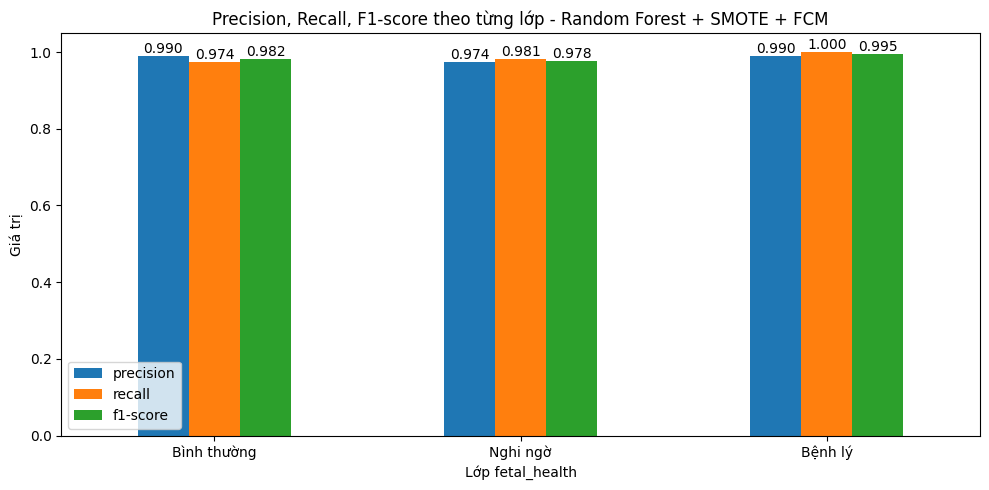

In [16]:
# =============================
# 3. Classification Report theo từng lớp
# =============================

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("Classification Report - Random Forest + SMOTE + MFCM:")
display(report_df)

# Lấy các dòng tương ứng với từng lớp
class_rows = [
    idx for idx in report_df.index
    if idx not in ['accuracy', 'macro avg', 'weighted avg']
]

class_metrics = report_df.loc[
    class_rows,
    ['precision', 'recall', 'f1-score', 'support']
]

# Đổi tên lớp cho dễ hiểu
if len(class_metrics.index) == 3:
    class_metrics.index = ['Bình thường', 'Nghi ngờ', 'Bệnh lý']

print("Chỉ số theo từng lớp:")
display(class_metrics)
# =============================
# 4. Vẽ Precision, Recall, F1-score theo từng lớp
# =============================

class_metrics_plot = class_metrics[['precision', 'recall', 'f1-score']]

ax = class_metrics_plot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title("Precision, Recall, F1-score theo từng lớp - Random Forest + SMOTE + FCM")
plt.xlabel("Lớp fetal_health")
plt.ylabel("Giá trị")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

XGBoot

In [17]:
y_train_xgb = y_train.astype(int) - 1
y_test_xgb = y_test.astype(int) - 1

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Khởi tạo model XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',   # dùng cho phân loại nhiều lớp
    num_class=len(y_train.unique()),
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

# Train model
xgb_model.fit(X_train_final, y_train_xgb)

# Predict
y_pred_xg = xgb_model.predict(X_test_final)

# Đánh giá
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xg))
print("Precision weighted:", precision_score(y_test_xgb, y_pred_xg, average='weighted'))
print("Recall weighted:", recall_score(y_test_xgb, y_pred_xg, average='weighted'))
print("F1 weighted:", f1_score(y_test_xgb, y_pred_xg, average='weighted'))

print("Precision macro:", precision_score(y_test_xgb, y_pred_xg, average='macro'))
print("Recall macro:", recall_score(y_test_xgb, y_pred_xg, average='macro'))
print("F1 macro:", f1_score(y_test_xgb, y_pred_xg, average='macro'))

print("\nDetail about one class:")
print("Classification Report:\n", classification_report(y_test_xgb, y_pred_xg))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_xgb, y_pred_xg))

Accuracy: 0.9882100750267953
Precision weighted: 0.9883282340934619
Recall weighted: 0.9882100750267953
F1 weighted: 0.9882266844610088
Precision macro: 0.9883282340934619
Recall macro: 0.9882100750267954
F1 macro: 0.9882266844610088

Detail about one class:
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       311
           1       0.97      0.99      0.98       311
           2       0.99      0.99      0.99       311

    accuracy                           0.99       933
   macro avg       0.99      0.99      0.99       933
weighted avg       0.99      0.99      0.99       933


Confusion Matrix:
 [[305   6   0]
 [  1 308   2]
 [  0   2 309]]


Classification Report - XGBoost + SMOTE + MFCM:


,precision,recall,f1-score,support
0,0.996732,0.980707,0.988655,311.00000
1,0.974684,0.990354,0.982456,311.00000
2,0.993569,0.993569,0.993569,311.00000
accuracy,0.988210,0.988210,0.988210,0.98821
macro avg,0.988328,0.988210,0.988227,933.00000
weighted avg,0.988328,0.988210,0.988227,933.00000


Chỉ số theo từng lớp - XGBoost + SMOTE + MFCM:


,precision,recall,f1-score,support
Bình thường,0.996732,0.980707,0.988655,311.0
Nghi ngờ,0.974684,0.990354,0.982456,311.0
Bệnh lý,0.993569,0.993569,0.993569,311.0


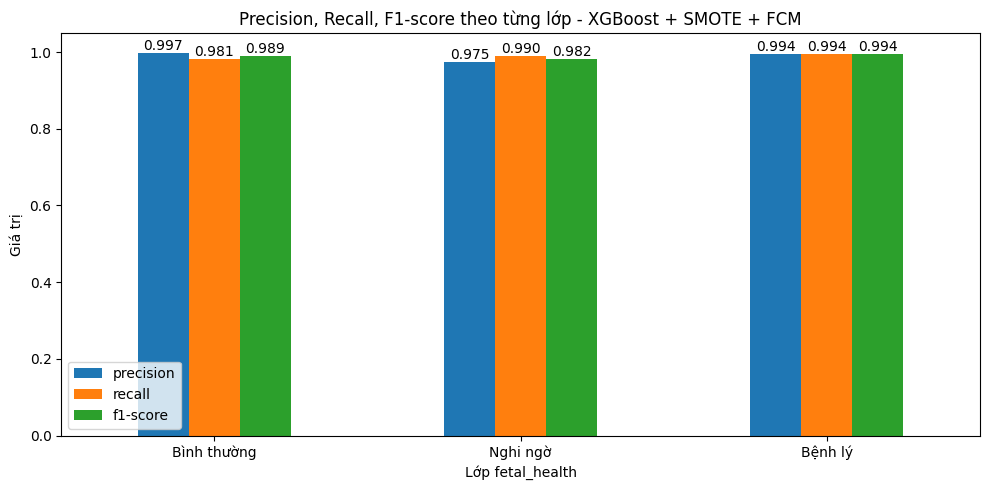

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

report_xgb_mfcm = classification_report(
    y_test_xgb,
    y_pred_xg,
    output_dict=True
)

report_xgb_mfcm_df = pd.DataFrame(report_xgb_mfcm).transpose()

print("Classification Report - XGBoost + SMOTE + MFCM:")
display(report_xgb_mfcm_df)

# Lấy các dòng theo từng lớp
class_rows = [
    idx for idx in report_xgb_mfcm_df.index
    if idx not in ['accuracy', 'macro avg', 'weighted avg']
]

class_metrics_xgb_mfcm = report_xgb_mfcm_df.loc[
    class_rows,
    ['precision', 'recall', 'f1-score', 'support']
]

# Đổi tên lớp cho dễ hiểu
if len(class_metrics_xgb_mfcm.index) == 3:
    class_metrics_xgb_mfcm.index = ['Bình thường', 'Nghi ngờ', 'Bệnh lý']

print("Chỉ số theo từng lớp - XGBoost + SMOTE + MFCM:")
display(class_metrics_xgb_mfcm)
# =============================
# 4. Biểu đồ Precision, Recall, F1-score theo từng lớp
# =============================

class_metrics_plot = class_metrics_xgb_mfcm[
    ['precision', 'recall', 'f1-score']
]

ax = class_metrics_plot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title("Precision, Recall, F1-score theo từng lớp - XGBoost + SMOTE + FCM")
plt.xlabel("Lớp fetal_health")
plt.ylabel("Giá trị")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


,PC1,PC2,Cluster,Max_Membership,fetal_health
0,0.067848,0.285815,2,0.554755,1
1,-0.426245,-0.272383,2,0.901429,2
2,1.431996,-0.301852,1,0.803282,3
3,0.620596,0.504235,1,0.696293,1
4,-0.915398,-0.399370,2,0.824012,3


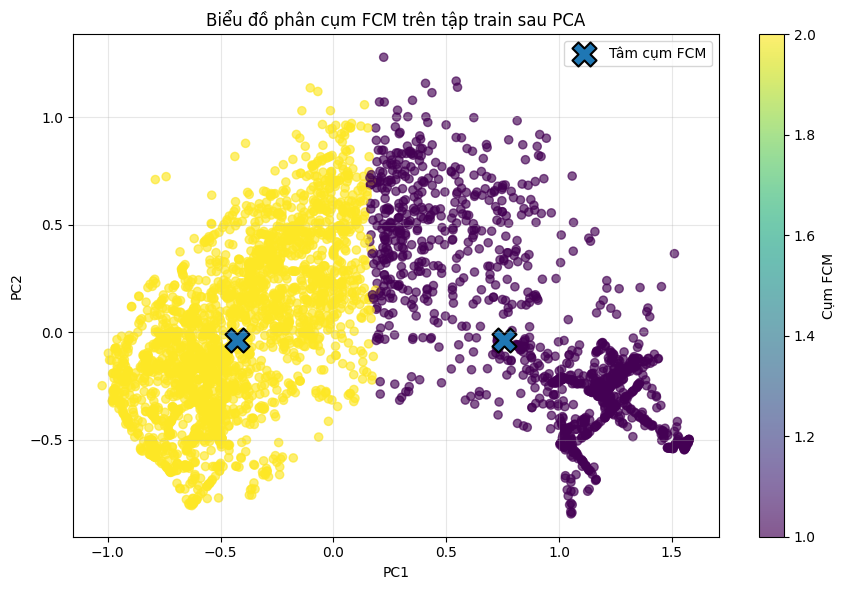

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =============================
# 1. Lấy membership FCM tập train
# =============================

U = U_train_fcm.copy()

# Mỗi mẫu thuộc mạnh nhất vào cụm nào
cluster_labels = np.argmax(U, axis=1) + 1

# Mức độ thuộc cụm mạnh nhất
max_membership = np.max(U, axis=1)

# =============================
# 2. PCA dữ liệu train về 2 chiều
# =============================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_train_scaled)

# Chiếu tâm cụm FCM xuống cùng không gian PCA
cntr_pca = pca.transform(cntr)

# =============================
# 3. Tạo DataFrame để xem
# =============================

fcm_plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels,
    "Max_Membership": max_membership,
    "fetal_health": y_train.values
})

display(fcm_plot_df.head())

# =============================
# 4. Vẽ biểu đồ
# =============================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    fcm_plot_df["PC1"],
    fcm_plot_df["PC2"],
    c=fcm_plot_df["Cluster"],
    s=35,
    alpha=0.65
)

plt.scatter(
    cntr_pca[:, 0],
    cntr_pca[:, 1],
    marker="X",
    s=300,
    edgecolors="black",
    linewidths=1.5,
    label="Tâm cụm FCM"
)

plt.title("Biểu đồ phân cụm FCM trên tập train sau PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cụm FCM")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Gộp để xem mô tả data sau fcm

In [21]:
# =============================
# Gộp X và y sau khi đã thêm membership FCM
# =============================

# Gộp train: X_train_final + y_train
train_final = pd.concat(
    [
        X_train_final,
        y_train.rename(target_col)
    ],
    axis=1
)


# Gộp test: X_test_final + y_test
test_final = pd.concat(
    [
        X_test_final,
        y_test.rename(target_col)
    ],
    axis=1
)


# Gộp toàn bộ train + test để xem dữ liệu tổng thể
data_final_with_fcm = pd.concat(
    [train_final, test_final],
    axis=0
)

# Sắp xếp lại theo index ban đầu nếu muốn dễ quan sát
data_final_with_fcm = data_final_with_fcm.sort_index()

print("Kích thước dữ liệu train sau khi gộp X + y:", train_final.shape)
print("Kích thước dữ liệu test sau khi gộp X + y:", test_final.shape)
print("Kích thước dữ liệu tổng thể sau khi thêm membership FCM:", data_final_with_fcm.shape)

print("\n5 dòng đầu dữ liệu tổng thể:")
display(data_final_with_fcm.head())

print("\nPhân bố lớp trong dữ liệu tổng thể:")
print(data_final_with_fcm[target_col].value_counts().sort_index())


Kích thước dữ liệu train sau khi gộp X + y: (3729, 24)
Kích thước dữ liệu test sau khi gộp X + y: (933, 24)
Kích thước dữ liệu tổng thể sau khi thêm membership FCM: (4662, 24)

5 dòng đầu dữ liệu tổng thể:


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fcm_cluster_1,fcm_cluster_2,fetal_health
0,0.259259,0.0000,0.0,0.000000,0.00,0.0,0.0,0.816003,0.071429,0.589041,...,0.142857,0.0,0.34,0.558824,0.301075,0.613445,1.0,0.399581,0.600419,2
1,0.481481,0.3750,0.0,0.428571,0.25,0.0,0.0,0.066886,0.452381,0.000000,...,0.428571,0.5,0.55,0.549020,0.505376,0.100840,0.5,0.624536,0.375464,1
2,0.500000,0.1875,0.0,0.571429,0.25,0.0,0.0,0.053508,0.452381,0.000000,...,0.357143,0.5,0.55,0.539216,0.483871,0.109244,0.5,0.625316,0.374684,1
3,0.518519,0.1875,0.0,0.571429,0.25,0.0,0.0,0.053508,0.523810,0.000000,...,0.785714,0.0,0.51,0.529412,0.473118,0.109244,1.0,0.576428,0.423572,1
4,0.481481,0.4375,0.0,0.571429,0.00,0.0,0.0,0.053508,0.523810,0.000000,...,0.642857,0.0,0.51,0.549020,0.483871,0.092437,1.0,0.551920,0.448080,1



Phân bố lớp trong dữ liệu tổng thể:
fetal_health
1    1554
2    1554
3    1554
Name: count, dtype: int64


In [22]:
data_final_with_fcm.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,4662.0,0.537218,0.194607,0.000000,0.404292,0.537037,0.703174,1.000000
accelerations,4662.0,0.091373,0.182089,0.000000,0.000000,0.000000,0.081916,1.000000
fetal_movement,4662.0,0.023704,0.068791,0.000000,0.000000,0.002702,0.018229,1.129496
uterine_contractions,4662.0,0.263146,0.216405,0.000000,0.054818,0.257945,0.428571,1.000000
light_decelerations,4662.0,0.160106,0.249475,0.000000,0.000000,0.000000,0.250000,1.000000
severe_decelerations,4662.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
prolongued_decelerations,4662.0,0.177635,0.358496,0.000000,0.000000,0.000000,0.000000,1.000000
abnormal_short_term_variability,4662.0,0.614341,0.216319,0.000000,0.508330,0.658330,0.742309,1.003283
mean_value_of_short_term_variability,4662.0,0.225863,0.215834,0.000000,0.047619,0.142857,0.333333,1.000000
percentage_of_time_with_abnormal_long_term_variability,4662.0,0.241898,0.308563,0.000000,0.000000,0.082192,0.424658,1.000000
